In [1]:
import os
import json
import pdb
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# Time series
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.api import AutoReg
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import TimeSeriesSplit

# SARIMAX 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

# LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import LSTM
from tensorflow.keras.optimizers import Adam
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler


# Jump Diffusion 
from sklearn.preprocessing import StandardScaler

# Process Track 
from tqdm import tqdm



def get_online_quantile(scores, q_1, etas, alpha):
    """
    Computes the online quantile of a set of scores.
    :param scores: (np.array) The scores.
    :param q_1: (float) The quantile to compute.
    :param eta: (np.array) The sequence of learning rates.
    :return: (float) The sequence of online quantiles.
    """
    T = scores.shape[0]
    q = np.zeros(T)
    q[0] = q_1
    for t in range(T):
        err_t = (scores[t] > q[t]).astype(int)
        if t < T - 1:
            q[t + 1] = q[t] - etas[t] * (alpha - err_t)
    return q


def compute_coverage_metrics(Y, Yhat, alpha, epsilon, W, C):
    """
    Compute online quantiles, observed coverages, long-run coverage (LRC), 
    rolling coverage, and time-conditional coverage.

    Parameters:
        scores (numpy array): Array of scores for the main dataset.
        scores_val (numpy array): Array of scores for the validation dataset.
        alpha (float): 1 - alpha is the desired coverage level.
        epsilon (float): Decay parameter for eta in the decaying quantile.
        W (int): Window size for rolling coverage computation.
        C: Constant of etas decaying 

    Returns:
        dict: Dictionary containing all computed metrics.
    """
    scores = np.abs(Y - Yhat)
    T = len(scores)
    #N_val = len(scores_val)
    
    # Define learning rates
    #etas_fixed = np.ones(T) * fixed_step_size
    etas_decaying = C * (np.array([1 / (t ** (1 / 2 + epsilon)) for t in range(1, T + 1)]))

    # Compute the oracle quantile
    #q_star = np.quantile(scores, 1 - alpha)
    
    # Initialize first quantile value
    q_1 = scores[0]

    # Compute online quantiles
    #q_fixed = get_online_quantile(scores, q_1, etas_fixed, alpha)
    q_decaying = get_online_quantile(scores, q_1, etas_decaying, alpha)

    # Compute observed coverage
    #observed_coverages_fixed = (scores <= q_fixed).astype(int)
    observed_coverages_decaying = (scores <= q_decaying).astype(int)
    #observed_coverages_oracle = (scores <= q_star).astype(int)

    # Compute long-run coverage
    #LRC_fixed = np.cumsum(observed_coverages_fixed) / (np.arange(len(observed_coverages_fixed)) + 1)
    LRC_decaying = np.cumsum(observed_coverages_decaying) / (np.arange(len(observed_coverages_decaying)) + 1)
    #LRC_qstar = np.cumsum(observed_coverages_oracle) / (np.arange(len(observed_coverages_oracle)) + 1)

    # Compute rolling coverage
    #rolling_coverage_fixed = smooth_array(observed_coverages_fixed, W)
    #rolling_coverage_decaying = smooth_array(observed_coverages_decaying, W)
    #rolling_coverage_oracle = smooth_array(observed_coverages_oracle, W)

    # Compute time-conditional coverage
    #time_coverage_fixed = (scores_val[:,None] <= q_fixed[None,:]).mean(axis=0)
    #time_coverage_decaying = (scores_val[:,None] <= q_decaying[None,:]).mean(axis=0)
    #time_coverage_qstar = (scores_val[:,None] <= q_star*np.ones_like(q_decaying)[None,:]).mean(axis=0)

    return {
        "T":T,
        #"q_fixed": q_fixed,
        "q_decaying": q_decaying,
        #"q_star": q_star,
        #"observed_coverages_fixed": observed_coverages_fixed,
        "observed_coverages_decaying": observed_coverages_decaying,
        #"observed_coverages_oracle": observed_coverages_oracle,
        #"LRC_fixed": LRC_fixed,
        "LRC_decaying": LRC_decaying,
        #"LRC_qstar": LRC_qstar,
        #"rolling_coverage_fixed": rolling_coverage_fixed,
        #"rolling_coverage_decaying": rolling_coverage_decaying,
        #"rolling_coverage_oracle": rolling_coverage_oracle,
        #"time_coverage_fixed": time_coverage_fixed,
        #"time_coverage_decaying": time_coverage_decaying,
        #"time_coverage_qstar": time_coverage_qstar
    }

def plot_coverage_results(results, alpha, W):
    """
    Plots the quantile evolution, long-run coverage
    for a single dataset using results from compute_coverage_metrics.

    Parameters:
        results (dict): Dictionary output from compute_coverage_metrics.
        alpha (float): 1 - alpha is the desired coverage level.
        W (int): Window size for rolling coverage computation.

    Returns:
        None (Displays the plot).
    """

    T = results['T']

    sns.set_style("white")
    sns.set_palette("Set2")

    # ---- Plot 1: Quantiles ----
    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["q_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    #plt.plot(range(T), results["q_star"] * np.ones_like(results["q_decaying"]), label=r'$q^*$')
    plt.ylabel(r'$q_t$')
    plt.xlabel(r'time $t$')
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

    # ---- Plot 2: Long-run coverage ----
    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["LRC_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    #plt.plot(range(T), results['LRC_qstar'], label=r'$q^*$')
    plt.axhline(y=1 - alpha, linestyle='dotted', color="k", linewidth=2, label=r'$1-\alpha$')
    plt.xlabel(r'time $t$')
    plt.ylabel("long-run coverage")
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()



def causal_ma(y, w):
    s = pd.Series(np.asarray(y, dtype=float))
    return s.rolling(window=w, min_periods=w).mean().shift(1).to_numpy()


# SARIMAX

def rolling_sarimax_forecast_recursive(data, train_size, p, d, q):
    """
    Perform rolling h-step recursive forecasting using SARIMAX.

    Parameters:
        data (pd.Series): Time series data.
        train_size (int): Initial training points.
        p, d, q (int): SARIMAX order.
        h (int): Forecast horizon (align with LSTM seq_length).

    Returns:
        np.array: Sequence of h-step-ahead predictions.
    """
    rolling_predictions = []
    train_data = data.iloc[:train_size].copy()

    sarimax_model = SARIMAX(train_data, order=(p, d, q),
                            enforce_stationarity=False,
                            enforce_invertibility=False).fit(disp=False)

    for t in tqdm(range(len(data) - train_size -4)):
        # make h recursive forecasts
        model_copy = sarimax_model 
        preds = []
        for step in range(5):
            next_pred = model_copy.forecast(steps=1).values[0]
            preds.append(next_pred)
            # feed prediction back instead of true obs
            model_copy = model_copy.append([next_pred], refit=False)

        # save the h-step-ahead prediction (align with horizon h)
        rolling_predictions.append(preds[-1])

        # update main model with the true next observation
        true_obs = data.iloc[train_size + t]
        sarimax_model = sarimax_model.append([true_obs], refit=False)

    return np.array(rolling_predictions)


from sklearn.metrics import mean_squared_error
import itertools
import numpy as np
import pandas as pd

def sarimax_grid_search(observed_data, y_true_test, train_size,
                        p_values, d_values, q_values,
                        verbose=True, return_table=False):
    """
    Grid search for SARIMAX using your rolling_sarimax_forecast().

    Parameters
    ----------
    observed_data : pd.Series or array-like
        Full observed series used to fit/append (length = n).
    y_true_test : pd.Series or array-like
        Ground-truth targets for t = train_size ... n-1
        (length should be n - train_size).
    train_size : int
        Initial training size used inside rolling_sarimax_forecast.
    p_values, d_values, q_values : list[int]
        Candidate SARIMAX orders.
    verbose : bool
        Print progress.
    return_table : bool
        If True, also return a DataFrame of all configs and RMSE.

    Returns
    -------
    best_cfg : tuple (p, d, q)
    best_score : float (RMSE)
    results_df : pd.DataFrame (optional)
    """
    # Coerce to proper dtypes
    if not isinstance(observed_data, pd.Series):
        observed_data = pd.Series(np.asarray(observed_data))
    y_true_test = np.asarray(y_true_test).astype(float)

    n = len(observed_data)
    expected_len = n - train_size
    if expected_len <= 0:
        raise ValueError(f"train_size={train_size} leaves no test points (n={n}).")

    # If user-provided y_true_test length differs, we'll align by truncation
    if len(y_true_test) != expected_len and verbose:
        print(f"⚠️  y_true_test length ({len(y_true_test)}) "
              f"!= expected ({expected_len}). Will align by min length.")
    results = []

    best_score, best_cfg = np.inf, None

    for p, d, q in itertools.product(p_values, d_values, q_values):
        try:
            preds = rolling_sarimax_forecast_recursive(observed_data, train_size, p, d, q)
            preds = np.asarray(preds).astype(float)

            # Check/align lengths
            m = min(len(preds), len(y_true_test))
            if m == 0:
                if verbose:
                    print(f"⏭️  Skipping SARIMAX({p},{d},{q}) — zero-length alignment.")
                continue

            y_true = y_true_test[-m:]
            y_pred = preds[-m:]

            rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
            results.append({"p": p, "d": d, "q": q, "rmse": rmse})

            if verbose:
                print(f"SARIMAX({p},{d},{q}) RMSE={rmse:.4f}")

            if rmse < best_score:
                best_score, best_cfg = rmse, (p, d, q)

        except Exception as e:
            if verbose:
                print(f"SARIMAX({p},{d},{q}) failed: {e}")
            continue

    if not results:
        raise RuntimeError("All configurations failed or produced empty predictions.")

    if verbose:
        print(f"✅ Best SARIMAX{best_cfg} RMSE={best_score:.4f}")

    if return_table:
        return best_cfg, best_score, pd.DataFrame(results).sort_values("rmse")
    return best_cfg, best_score

def create_sequences(data, seq_length, train_ratio=0.8):
    data = np.array(data)  # ensure numpy
    data_len = len(data)
    train_size = int(data_len * train_ratio)

    train_data = data[:train_size]
    test_data  = data[train_size:]  # strict split

    # Training sequences
    X_train, y_train = [], []
    for i in range(len(train_data) - seq_length):
        X_train.append(train_data[i:i+seq_length])
        y_train.append(train_data[i+seq_length])

    # Testing sequences
    X_test, y_test = [], []
    for i in range(len(test_data) - seq_length):
        X_test.append(test_data[i:i+seq_length])
        y_test.append(test_data[i+seq_length])

    # Reshape for LSTM [samples, timesteps, features]
    X_train = np.array(X_train).reshape(-1, seq_length, 1)
    y_train = np.array(y_train)
    X_test  = np.array(X_test).reshape(-1, seq_length, 1)
    y_test  = np.array(y_test)

    return X_train, X_test, y_train, y_test


# COMA 


def hedge(loss_matrix, eta):
    """
    Hedge algorithm.

    Parameters
    ----------
    loss_matrix : np.ndarray
        Shape (N, K), loss of K experts during N rounds.
    eta : float
        Learning rate parameter.

    Returns
    -------
    dict
        h : np.ndarray of shape (N,)
            Weighted average loss at each round.
        weights : np.ndarray of shape (N, K)
            Expert weights at each round.
    """
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)          # vector of length N
    weights = np.full((N, K), np.nan)  # N x K matrix
    w = np.full(K, 1.0 / K)         # start uniform weights

    for t in range(N):
        weights[t, :] = w
        w = w * np.exp(-eta * loss_matrix[t, :])  # exponential weighting
        w = w / np.sum(w)                         # normalize
        h[t] = np.sum(w * loss_matrix[t, :])      # weighted average loss

    return {"h": h, "weights": weights}


def counts_int(M, a, b, w):
    """
    Compute weighted fraction of intervals in M that cover the midpoint of [a,b].
    
    Parameters
    ----------
    M : np.ndarray
        Shape (n, 2), intervals with lower and upper bounds.
    a, b : float
        Interval boundaries.
    w : np.ndarray
        Weights for each interval (length n).
    
    Returns
    -------
    float
        Weighted mean (between 0 and 1).
    """
    mid = 0.5 * (a + b)
    inside = (M[:, 0] <= mid) & (mid <= M[:, 1]) 
    inside = inside.astype(float)                  
    num_int = np.average(inside, weights=w)
    return num_int


def mix(L, eta):
    """
    Python translation of R mix().
    """
    mn = np.min(L)

    if np.isinf(eta):
        w = (L == mn).astype(float)
        w /= w.sum()
    else:
        w = np.exp(-eta * (L - mn))

    s = np.sum(w)
    w = w / s
    M = mn - (1.0 / eta) * np.log(s / len(L)) if not np.isinf(eta) else mn

    return {"w": w, "M": M}

def adahedge(loss_matrix):
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)
    L = np.zeros(K)
    etas = np.full(N, np.nan)
    weights = np.full((N, K), np.nan)
    Delta = 0.0

    for t in range(N):
        eta = np.log(K) / Delta if Delta > 0 else np.inf
        result = mix(L, eta=eta)
        w, Mprev = result["w"], result["M"]

        h[t] = np.dot(w, loss_matrix[t])
        weights[t] = w
        L = L + loss_matrix[t]

        result = mix(L, eta=eta)
        delta = max(0.0, h[t] - (result["M"] - Mprev))
        Delta += delta
        etas[t] = eta

    return {"h": h, "weights": weights, "eta": etas}



def majority_vote(M, w, rho):
    breaks = np.unique(M.flatten())
    breaks.sort()

    lower, upper = [], []

    if np.mean(np.isinf(M[:, 1])) > rho:
        return np.array([[-np.inf, np.inf]])

    i = 0
    while i < len(breaks) - 1:
        cond = counts_int(M, breaks[i], breaks[i+1], w) > rho
        if cond:
            lower.append(breaks[i])
            j = i
            while j < len(breaks) - 1 and cond:
                j += 1
                if j < len(breaks) - 1:   
                    cond = counts_int(M, breaks[j], breaks[j+1], w) > rho
                else:
                    cond = False
            upper.append(breaks[j])
            i = j
        i += 1

    if not lower:
        return np.nan
    else:
        return np.column_stack([lower, upper])


def covr_fun(ci, target):
    """
    Coverage function: check if target lies inside interval(s).
    
    ci: np.ndarray (L, 2) or (2,), interval(s)
    target: float, true value
    
    Returns: 1 if covered, 0 otherwise
    """
    if isinstance(ci, float) and np.isnan(ci):
        return 0

    ci = np.atleast_2d(ci)
    covr = 0
    for l, u in ci:
        covr += int((l <= target) and (target <= u))
    return covr

import numpy as np

def loss_fun(ci):
    """
    Compute the width of confidence interval(s).
    
    Parameters
    ----------
    ci : np.ndarray or list
         - shape (2,)   → single interval [low, high]
         - shape (L, 2) → multiple intervals
         - np.nan       → no interval
    
    Returns
    -------
    float
        total width (sum of all intervals' widths)
    """

    if ci is None or (isinstance(ci, float) and np.isnan(ci)):
        return 0.0
    ci = np.atleast_2d(ci)
    
    width = 0.0
    for l, u in ci:
        if np.isnan(l) or np.isnan(u):
            continue
        width += (u - l)
    return width

import numpy as np

def coma_loop(intervals_list, weights, data_y):
    """
    COMA aggregation loop (Python translation of the R code).
    
    intervals_list: list of arrays [N x 2], one for each expert's intervals
    weights: array [N x K], AdaHedge weights
    data_y: array of true outcomes
    """
    N, K = weights.shape
    pi_m, pi_wm = [], []
    m_cov, wm_cov = [], []

    for i in range(N):
        # stack intervals from all experts for round i
        conf_t = np.vstack([intervals[i] for intervals in intervals_list])

        # deterministic majority vote (rho=0.5 for strict majority)
        maj_int = majority_vote(conf_t, w=weights[i], rho=0.5)

        # randomized majority vote (rho ∈ [0.5,1])
        rho_rand = np.random.uniform(0.5, 1.0)
        wmaj_int = majority_vote(conf_t, w=weights[i], rho=rho_rand)

        # store intervals
        pi_m.append(maj_int)
        pi_wm.append(wmaj_int)

        # coverage check (ensure index alignment!)
        target_idx = i
        if target_idx < len(data_y):
            m_cov.append(covr_fun(maj_int, data_y[target_idx]))
            wm_cov.append(covr_fun(wmaj_int, data_y[target_idx]))
        else:
            m_cov.append(0)
            wm_cov.append(0)

    return {
        "pi_m": pi_m,
        "pi_wm": pi_wm,
        "m_cov": np.array(m_cov),
        "wm_cov": np.array(wm_cov),
        "mean_m_cov": np.mean(m_cov),
        "mean_wm_cov": np.mean(wm_cov)
    }


# Simple average ensemble 

def simple_average_ensemble(predictions):
    """
    Simple average ensemble of multiple model predictions.

    Parameters:
        predictions (list of np.array): List of prediction arrays from different models.

    Returns:
        np.array: Ensemble predictions obtained by averaging.
    """
    return np.mean(predictions, axis=0)


# Experiment

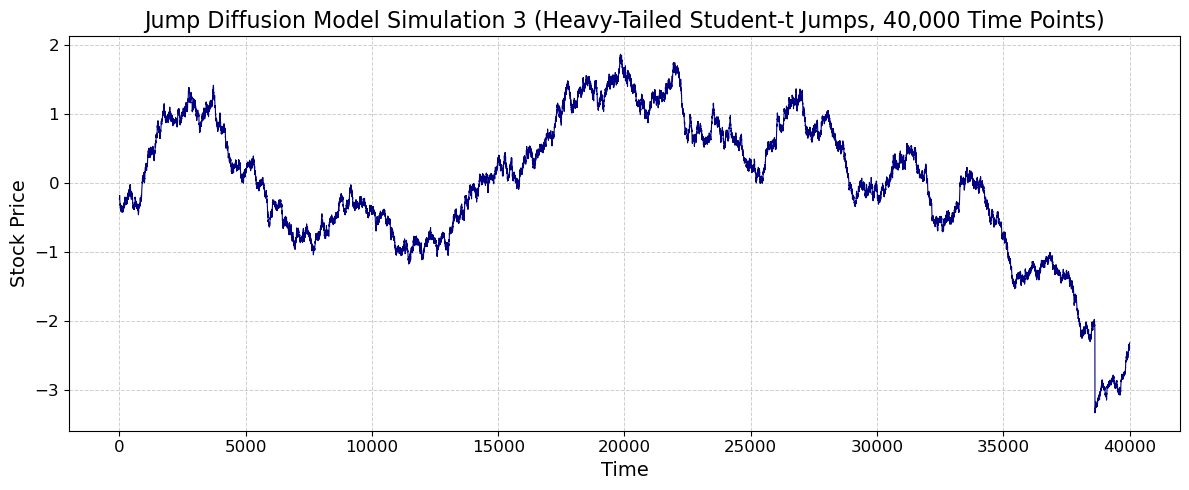

Train dataset shape: (32000,), Test dataset shape: (8000,)


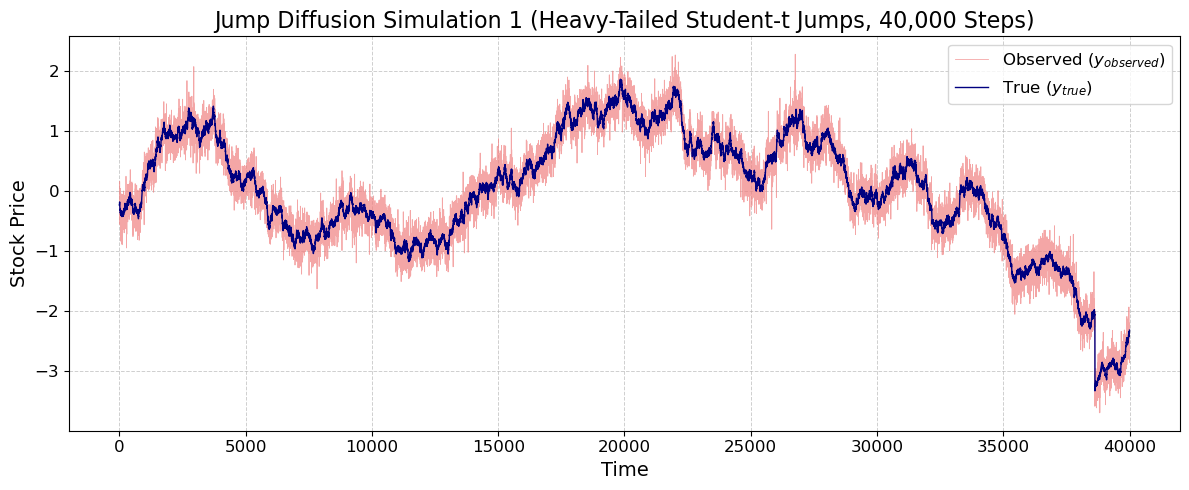

In [2]:
# Set seed for reproducibility
np.random.seed(42)

# Parameters
S0 = 100                # initial stock price
mu = 0.05               # drift
sigma = 0.2             # volatility
lamb = 0.5              # jump intensity
df_t = 2                # degrees of freedom for heavy-tailed t distribution
scale_t = 0.3           # scale parameter for t-distribution
T = 1.0                 # total time
N = 40000               # number of time steps
dt = T / N              # time step


# Time grid
t = np.arange(N)

# Brownian increments
dW = np.random.normal(0, np.sqrt(dt), N)
# Poisson jump component
N_jumps = np.random.poisson(lamb * dt, N)  # 0 or 1 jumps per step
J = np.random.standard_t(df_t, size=N) * scale_t   # heavy-tailed jump sizes (Student's t)
jump_component = (np.exp(J) - 1) * N_jumps

# Initialize price path
S = np.zeros(N)
S[0] = S0

# Simulate path
for i in range(1, N):
    S[i] = S[i-1] * (1 + mu * dt + sigma * dW[i] + jump_component[i])

scaler = StandardScaler()
S_sd = scaler.fit_transform(S.reshape(-1, 1)).flatten()


data_jd_sd = pd.DataFrame({'x': t, 'y': S_sd})
# y_observed = y + noise 
# y_true 

# Plot
plt.figure(figsize=(12, 5))

# Plot with publication style
plt.plot(data_jd_sd['x'], data_jd_sd['y'], color="navy", linewidth=0.8)

# Titles and labels
plt.title('Jump Diffusion Model Simulation 3 (Heavy-Tailed Student-t Jumps, 40,000 Time Points)', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Stock Price', fontsize=14)

# Grid & frame
plt.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=12)

# Clean frame
plt.tight_layout()
plt.show()


# Train-test split 
sigma_t = np.exp(-2 + 0.3 * np.random.normal(size=N))  # mean ≈ 0.14, clustering still present
noise = np.random.normal(0, sigma_t, size=N)
y_observed = data_jd_sd['y'] + noise 
train_size3 = int(0.8 * len(y_observed))
test_size = int(0.2 * len(y_observed))

y_train_sim3 = y_observed[:train_size3]
y_test_sim3 = y_observed[train_size3:]
y_true = data_jd_sd['y'].to_numpy()
y_true_test = data_jd_sd['y'].to_numpy()[train_size3:] 


print(f"Train dataset shape: {y_train_sim3.shape}, Test dataset shape: {y_test_sim3.shape}")

plt.figure(figsize=(12, 5))

# Plot observed series (noisy)
plt.plot(data_jd_sd['x'], y_observed, 
         color="lightcoral", linewidth=0.6, alpha=0.7, 
         label="Observed ($y_{observed}$)")

# Plot clean series (true trajectory)
plt.plot(data_jd_sd['x'], data_jd_sd['y'], 
         color="navy", linewidth=1.0, 
         label="True ($y_{true}$)")

# Titles and labels
plt.title('Jump Diffusion Simulation 1 (Heavy-Tailed Student-t Jumps, 40,000 Steps)', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Stock Price', fontsize=14)

# Grid, legend, and formatting
plt.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# LSTM(3 base learners)

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


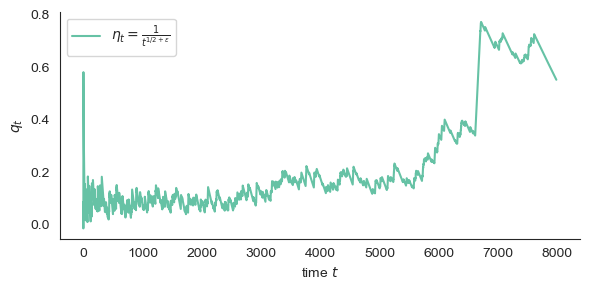

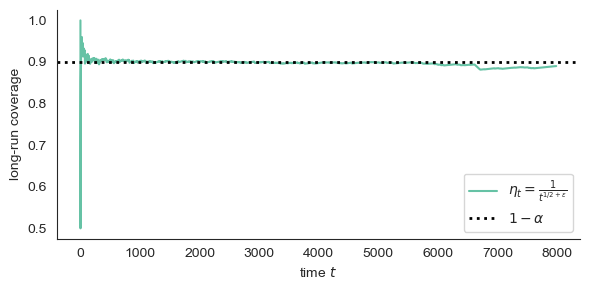

Model 1 mean CI width: 0.24151629078271264
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


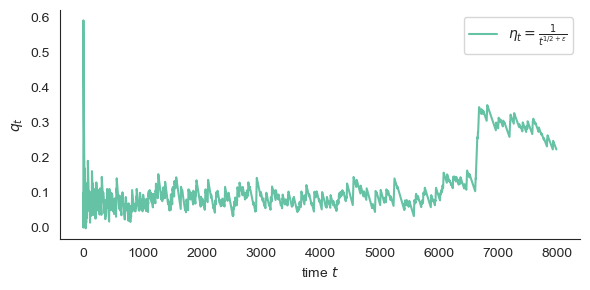

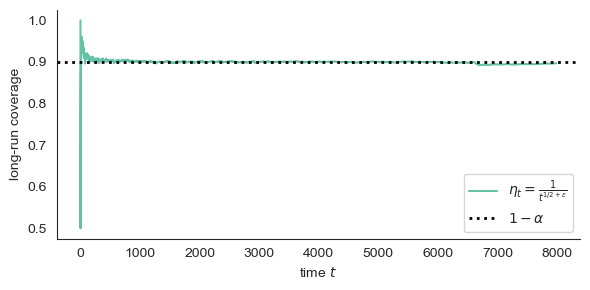

Model 2 mean CI width: 0.1215805420864998
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step


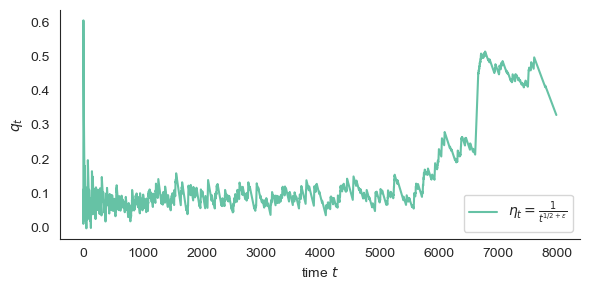

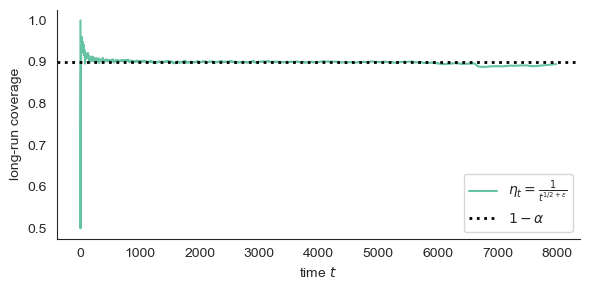

Model 3 mean CI width: 0.16344407039688863


In [3]:
import os, random, numpy as np, tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
tf.keras.backend.clear_session()

#  Global reproducibility helper
def set_global_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


seq_length = 15
X_train, X_test, y_train, y_test = create_sequences(y_observed, seq_length, train_ratio=0.8)

#  Model 1: Deep + tanh (long memory)

set_global_seed(42) 
model1 = Sequential([
    LSTM(256, activation='tanh', return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.1),
    LSTM(64, activation='tanh'),
    Dropout(0.1),
    Dense(1)
])
model1.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')
history1 = model1.fit(X_train, y_train, epochs=6, batch_size=16, verbose=0)
y_pred_lstm1 = model1.predict(X_test).flatten()

results_jd_lstm1 = compute_coverage_metrics(y_true_test[seq_length:], y_pred_lstm1, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_jd_lstm1, alpha=0.1, W=1000)
print("Model 1 mean CI width:", np.mean(results_jd_lstm1['q_decaying']))
CI_lstm_decaying_model1 = results_jd_lstm1['q_decaying'] * 2


#  Model 2: Mid-depth + relu (nonlinear learner)

model2 = Sequential([
    LSTM(128, activation='elu', return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.1),
    LSTM(32, activation='elu'),
    Dropout(0.1),
    Dense(1)
])
model2.compile(optimizer=Adam(learning_rate=0.0002), loss='mean_squared_error')
history2 = model2.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0)
y_pred_lstm2 = model2.predict(X_test).flatten()

results_jd_lstm2 = compute_coverage_metrics(y_true_test[seq_length:], y_pred_lstm2, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_jd_lstm2, alpha=0.1, W=1000)
print("Model 2 mean CI width:", np.mean(results_jd_lstm2['q_decaying']))
CI_lstm_decaying_model2 = results_jd_lstm2['q_decaying'] * 2


#  Model 3: Compact + relu (fast short-term learner)
model3 = Sequential([
    LSTM(32, activation='relu', input_shape=(seq_length, 1)),
    Dropout(0.1),
    Dense(1)
])
model3.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
history3 = model3.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
y_pred_lstm3 = model3.predict(X_test).flatten()

results_jd_lstm3 = compute_coverage_metrics(y_true_test[seq_length:], y_pred_lstm3, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_jd_lstm3, alpha=0.1, W=1000)
print("Model 3 mean CI width:", np.mean(results_jd_lstm3['q_decaying']))
CI_lstm_decaying_model3 = results_jd_lstm3['q_decaying'] * 2


In [4]:
# coverage checks

print(f"coverage for lstm1", np.mean(results_jd_lstm1['observed_coverages_decaying']))
print(f"coverage for lstm2", np.mean(results_jd_lstm2['observed_coverages_decaying']))
print(f"coverage for lstm3", np.mean(results_jd_lstm3['observed_coverages_decaying']))

CI_lstm_decaying_model1 = results_jd_lstm1['q_decaying'] * 2
print(np.mean(CI_lstm_decaying_model1))

CI_lstm_decaying_model2 = results_jd_lstm2['q_decaying'] * 2
print(np.mean(CI_lstm_decaying_model2))

CI_lstm_decaying_model3 = results_jd_lstm3['q_decaying'] * 2
print(np.mean(CI_lstm_decaying_model3))

coverage for lstm1 0.8901690670006261
coverage for lstm2 0.8969317470256731
coverage for lstm3 0.8948027551659361
0.4830325815654253
0.2431610841729996
0.32688814079377726


# Simple Average

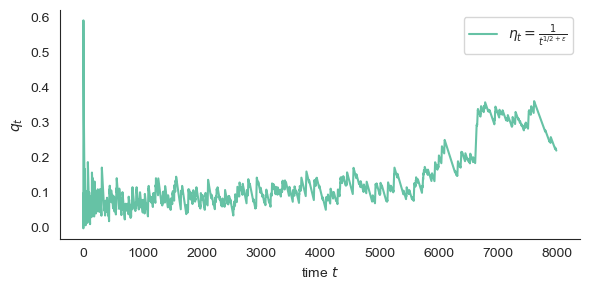

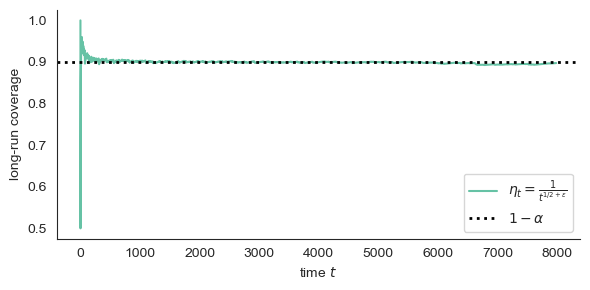

0.14361489768061267


In [5]:
y_sa_pred_ensemble = simple_average_ensemble([y_pred_lstm1, y_pred_lstm2, y_pred_lstm3])
results_sa_lstm = compute_coverage_metrics(y_true_test[seq_length:], y_sa_pred_ensemble, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_sa_lstm, alpha=0.1, W=1000)
print(np.mean(results_sa_lstm['q_decaying']))
CI_sa_decaying = results_sa_lstm['q_decaying'] * 2

# Super Learner

Fold 0: train=5335, val=5333
Epoch 1/6
333/333 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0508
Epoch 2/6
333/333 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0286
Epoch 3/6
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0284
Epoch 4/6
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0281
Epoch 5/6
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0279
Epoch 6/6
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0286
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Epoch 1/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1457
Epoch 2/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0298
Epoch 3/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0286
Epoch 4/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0292
Epoch 5/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0286
Epoch 6/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0282
Epoch 7/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0282
Epoch 8/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss:

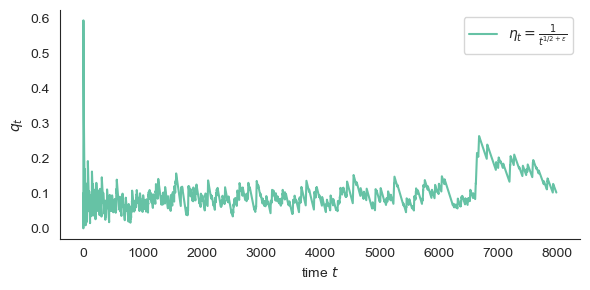

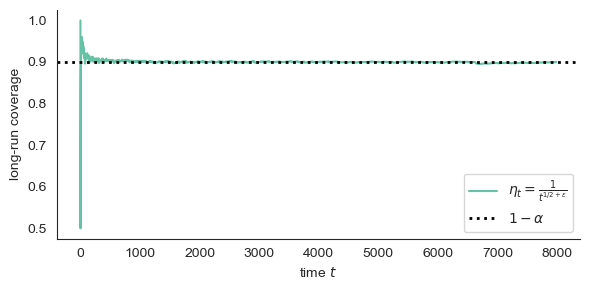

In [6]:
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from scipy.optimize import minimize
import numpy as np


# --- Optimize convex weights ---
def optimize_weights(X, y, alpha1=0.0, alpha2=0.0):
    init_phi = np.ones(X.shape[1]) / X.shape[1]
    def mse_loss(phi):
        y_pred = X @ phi
        mse = np.mean((y - y_pred) ** 2)
        l1 = alpha1 * np.sum(np.abs(phi))
        l2 = alpha2 * np.sum(phi**2)
        return mse + l1 + l2
    constraints = [{'type': 'eq', 'fun': lambda phi: np.sum(phi) - 1}]
    bounds = [(0, 1)] * X.shape[1]
    result = minimize(mse_loss, init_phi, bounds=bounds, constraints=constraints)
    return result.x


# --- Define each fixed LSTM base learner ---
def build_lstm_model(model_id, seq_length):
    if model_id == 1:   # Deep + tanh
        return Sequential([
                LSTM(256, activation='tanh', return_sequences=True, input_shape=(seq_length, 1)),
                Dropout(0.1),
                LSTM(64, activation='tanh'),
                Dropout(0.1),
                Dense(1)
                ]), Adam(learning_rate=0.0005), 6, 16

    elif model_id == 2: # Shallow + relu
        return Sequential([
                    LSTM(128, activation='elu', return_sequences=True, input_shape=(seq_length, 1)),
                    Dropout(0.1),
                    LSTM(32, activation='elu'),
                    Dropout(0.1),
                    Dense(1)
        ]), Adam(learning_rate=0.0002), 10, 16

    elif model_id == 3: # Compact + relu
        return Sequential([
                    LSTM(32, activation='relu', input_shape=(seq_length, 1)),
                    Dropout(0.1),
                    Dense(1)
        ]), Adam(learning_rate=0.001), 10, 32


# --- Super Learner with 3 LSTM base learners ---
def super_learner_lstm(y, seq_length=15, n_splits=5):
    """
    Super Learner with 3 fixed LSTM base learners (your three definitions).
    """
    # Build sequences
    X_all, _, y_all, _ = create_sequences(y, seq_length, train_ratio=0.8)
    n_total = len(y)
    train_size = int(0.8 * n_total)
    y_train, y_test = y[:train_size], y[train_size:]

    tscv = TimeSeriesSplit(n_splits=n_splits)
    meta_features = np.full((train_size - seq_length, 3), np.nan)

    # --- 1. Cross-validation (OOF predictions) ---
    for fold, (train_idx, val_idx) in enumerate(tscv.split(y_train)):
        print(f"Fold {fold}: train={len(train_idx)}, val={len(val_idx)}")
        # Map sequence indices
        tr_rows = train_idx[train_idx >= seq_length] - seq_length
        va_rows = val_idx[val_idx >= seq_length] - seq_length

        X_tr, y_tr = X_all[tr_rows], y_all[tr_rows]
        X_va, y_va = X_all[va_rows], y_all[va_rows]

        # Train each of the 3 base LSTMs on this fold
        for i in range(3):
            model, opt, epochs, batch_size = build_lstm_model(i+1, seq_length)
            model.compile(optimizer=opt, loss='mse')
            model.fit(X_tr, y_tr, epochs=epochs, batch_size=batch_size)
            preds_val = model.predict(X_va).flatten()
            meta_features[va_rows, i] = preds_val

    # Drop NaNs
    valid_rows = ~np.isnan(meta_features).any(axis=1)
    X_meta = meta_features[valid_rows]
    y_meta = y_train[seq_length:][valid_rows]

    # --- 2. Meta-learning (learn convex weights) ---
    meta_weights = optimize_weights(X_meta, y_meta)
    print("Final meta-learner weights:", meta_weights)

    # --- 3. Final refit on full training set ---
    X_train_full, X_test_full, y_train_full, y_test_full = create_sequences(y, seq_length, train_ratio=0.8)
    full_preds = []

    for i in range(3):
        model, opt, epochs, batch_size = build_lstm_model(i+1, seq_length)
        model.compile(optimizer=opt, loss='mse')
        model.fit(X_train_full, y_train_full, epochs=epochs, batch_size=batch_size)
        preds = model.predict(X_test_full).flatten()
        full_preds.append(preds)

    # Stack base learner preds for test
    X_test_meta = np.column_stack(full_preds)
    super_preds = X_test_meta @ meta_weights
    return super_preds, meta_weights


# --- Usage ---
y = y_observed.to_numpy()
super_preds_lstm, meta_weights_lstm = super_learner_lstm(y, seq_length=15, n_splits=5)

# Evaluate coverage
results_super_lstm = compute_coverage_metrics(
    y_true_test[seq_length:], super_preds_lstm,
    alpha=0.1, epsilon=0.1, W=1000, C=1
)
plot_coverage_results(results_super_lstm, alpha=0.1, W=1000)

# Comparison

0.2051891044951414


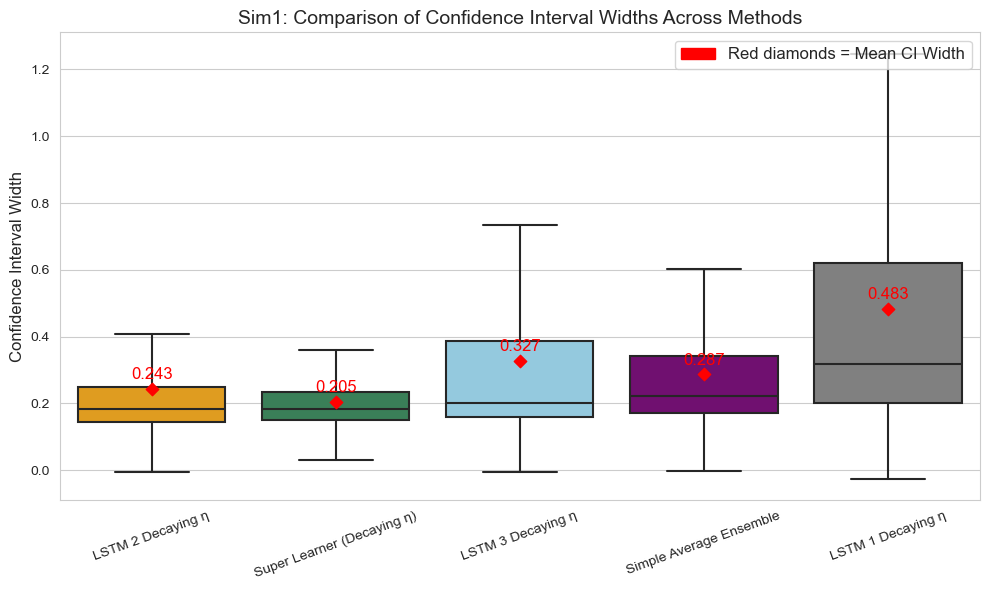

In [7]:
CI_sp_decaying = results_super_lstm['q_decaying'] * 2 
print(np.mean(CI_sp_decaying))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
# Step 1: Collect all CI width arrays into a dictionary
data_dict = {
    "LSTM 1 Decaying η": CI_lstm_decaying_model1,
    "LSTM 2 Decaying η": CI_lstm_decaying_model2,
    "LSTM 3 Decaying η": CI_lstm_decaying_model3,
    "Simple Average Ensemble": CI_sa_decaying,
    "Super Learner (Decaying η)": CI_sp_decaying
}

# Step 2: Convert to long-format DataFrame
df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")

# Step 3: Define custom order by median CI width
order = df_long.groupby("Method")["CI Width"].median().sort_values().index

# Step 4: Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
palette = {
    "LSTM 1 Decaying η": "gray",
    "LSTM 2 Decaying η": "orange",
    "LSTM 3 Decaying η": "skyblue",
    "Simple Average Ensemble": "purple",
    "Super Learner (Decaying η)": "seagreen"
}

ax = sns.boxplot(x="Method", y="CI Width", data=df_long, order=order,
                 palette=palette, showfliers=False)

# Add mean points
means = df_long.groupby("Method")["CI Width"].mean()
for i, method in enumerate(order):
    ax.scatter(i, means[method], color="red", marker="D", s=40, zorder=3)
    ax.text(i, means[method]+0.02, f"{means[method]:.3f}",
            ha='center', va='bottom', fontsize=12, color="red")

# Step 5: Add custom legend entry for red mean points
mean_patch = mpatches.Patch(color='red', label='Red diamonds = Mean CI Width')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [mean_patch], labels + ['Red diamonds = Mean CI Width'],
          loc='upper right', fontsize=12, frameon=True)

# Step 6: Enhance readability
plt.title("Sim1: Comparison of Confidence Interval Widths Across Methods", fontsize=14)
plt.xlabel("")
plt.ylabel("Confidence Interval Width", fontsize=12)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# Coma 

Mean deterministic coverage: 0.8964308077645585
Mean randomized coverage: 0.8963055729492799
Mean CI width — COMA (det): 0.24322189930043125
Mean CI width — COMA (rand): 0.24296071083378867
Mean CI width — Super Learner: 0.2051891044951414


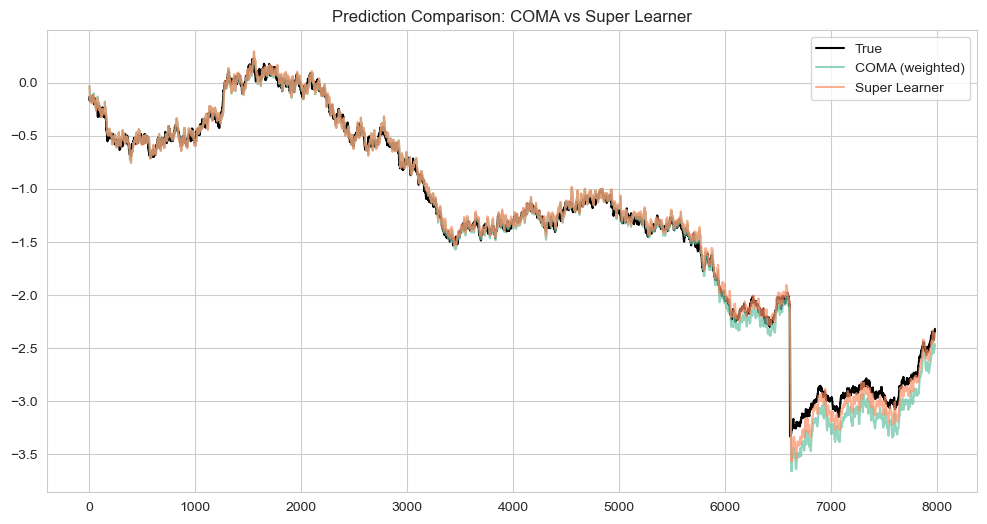

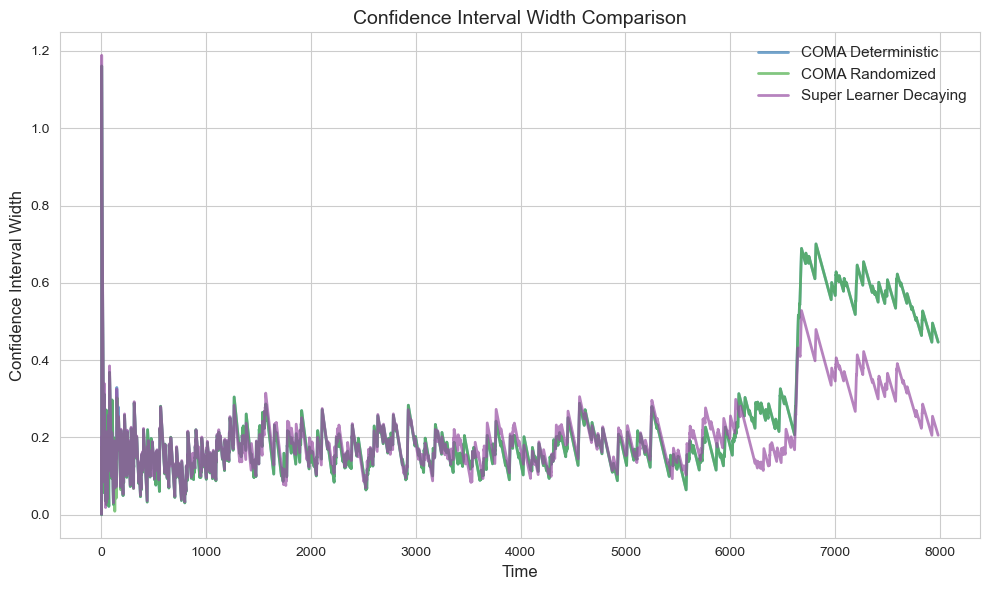

In [8]:
colors = sns.color_palette("Set1", 4)
# --- Step 1: Minimum aligned length ---
min_len = min(
    len(results_jd_lstm1['q_decaying']),
    len(results_jd_lstm2['q_decaying']),
    #len(results_jd_srm_model2['q_decaying']),
    len(results_jd_lstm3['q_decaying']),
    #len(results_jd_lstm3_model2['q_decaying']),
    len(CI_sp_decaying),
    len(y_true_test)
)

# --- Step 2: CI half-widths (2 * q_decaying) ---
ci_matrix = np.column_stack([
    CI_lstm_decaying_model1[-min_len:],
    CI_lstm_decaying_model2[-min_len:],
    #2 * results_jd_srm_model2['q_decaying'][-min_len:],
    CI_lstm_decaying_model3[-min_len:],
    #2 * results_jd_lstm3_model2['q_decaying'][:min_len]

])
adahedAlg = adahedge(loss_matrix=ci_matrix)

intervals_lstm1 = np.column_stack([
    y_pred_lstm1[-min_len:] 
    - results_jd_lstm1['q_decaying'][-min_len:],
    y_pred_lstm1[-min_len:] 
    + results_jd_lstm1['q_decaying'][-min_len:]
])

intervals_lstm2 = np.column_stack([
    y_pred_lstm2[-min_len:] - results_jd_lstm2['q_decaying'][-min_len:],
    y_pred_lstm2[-min_len:] + results_jd_lstm2['q_decaying'][-min_len:]
])

intervals_lstm3 = np.column_stack([
    y_pred_lstm3[-min_len:] - results_jd_lstm3['q_decaying'][-min_len:],
    y_pred_lstm3[-min_len:] + results_jd_lstm3['q_decaying'][-min_len:]
])


intervals_list_plain = [intervals_lstm1, intervals_lstm2, intervals_lstm3]
weights_plain = adahedAlg["weights"]

# --- Step 5: Align test labels ---
y_test_aligned = y_true_test[-min_len:]

# --- Step 6: Run COMA ---
result_plain = coma_loop(intervals_list_plain, weights_plain, y_test_aligned)

print("Mean deterministic coverage:", result_plain["mean_m_cov"])
print("Mean randomized coverage:", result_plain["mean_wm_cov"])

# --- Step 7: Compute widths ---
pi_m   = result_plain["pi_m"]
pi_wm  = result_plain["pi_wm"]

coma_width_det  = np.array([loss_fun(ci) for ci in pi_m])
coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm])

CI_super_decaying = CI_sp_decaying[-min_len:]

print("Mean CI width — COMA (det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — Super Learner:", np.mean(CI_super_decaying))

base_preds_matrix = np.column_stack([
    y_pred_lstm1[-min_len:],
    y_pred_lstm2[-min_len:],
    y_pred_lstm3[-min_len:]
])
# Case 1: weights_plain is shape (n, k)
coma_preds_weighted = np.sum(base_preds_matrix * weights_plain, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(y_test_aligned, label="True", color="black")
plt.plot(coma_preds_weighted, label="COMA (weighted)", alpha=0.7)
plt.plot(super_preds_lstm[-min_len:], label="Super Learner", alpha=0.7)
plt.legend()
plt.title("Prediction Comparison: COMA vs Super Learner")
plt.show()

# --- Step 8: Plot ---
plt.figure(figsize=(10, 6))

plt.plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha = 0.7, color=colors[1])
plt.plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha = 0.7, color=colors[2])
plt.plot(CI_super_decaying, label='Super Learner Decaying', linewidth=2, alpha = 0.7, color=colors[3])

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
plt.title('Confidence Interval Width Comparison', fontsize=14)

plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

Mean deterministic coverage: 0.8964308077645585
Mean randomized coverage: 0.8960551033187226
Mean CI width — COMA (det): 0.24322189930043125
Mean CI width — COMA (rand): 0.24297659359292748
Mean CI width — Super Learner: 0.2051891044951414


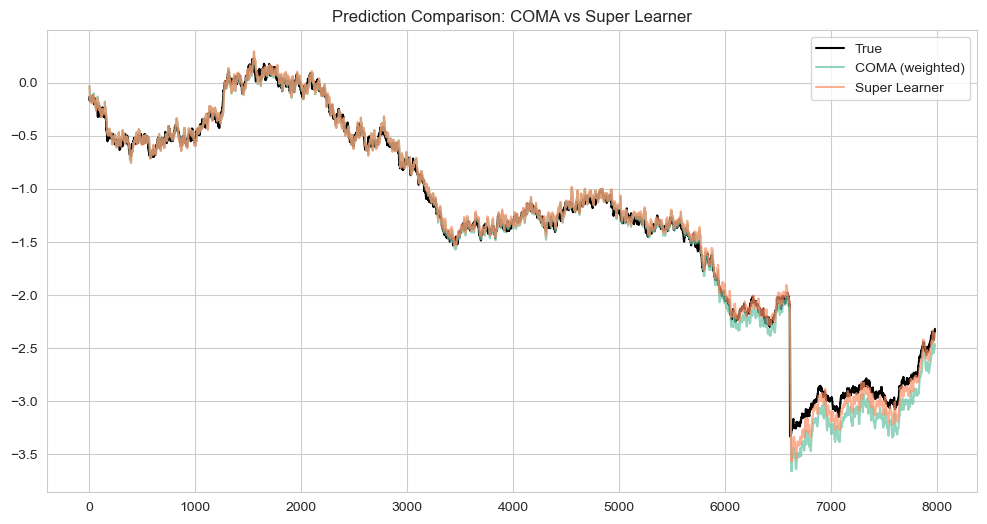

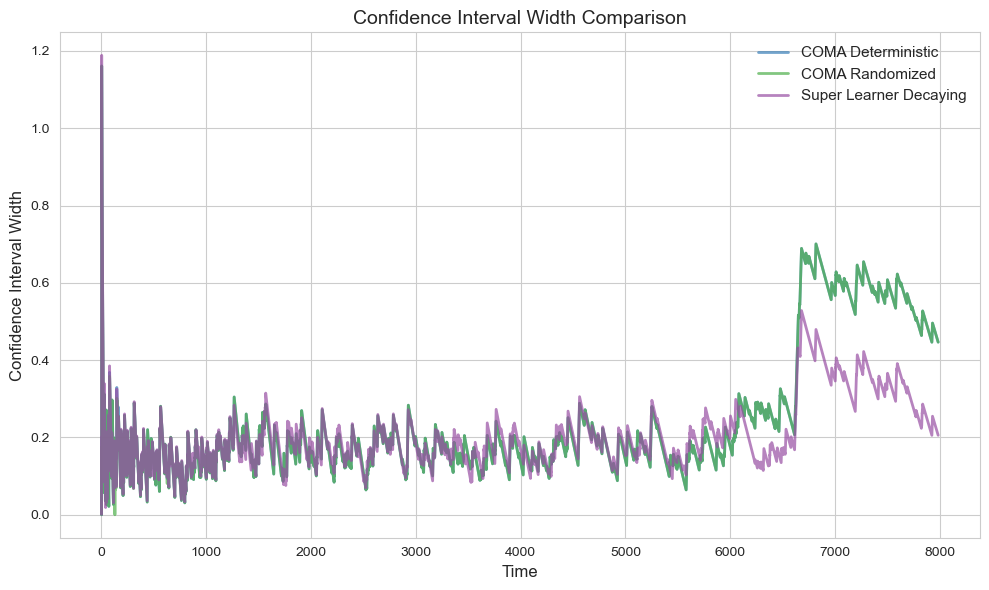

In [9]:
colors = sns.color_palette("Set1", 4)
# --- Step 1: Minimum aligned length ---
min_len = min(
    len(results_jd_lstm1['q_decaying']),
    len(results_jd_lstm2['q_decaying']),
    #len(results_jd_srm_model2['q_decaying']),
    len(results_jd_lstm3['q_decaying']),
    #len(results_jd_lstm3_model2['q_decaying']),
    len(CI_sp_decaying),
    len(y_true_test)
)

# --- Step 2: CI half-widths (2 * q_decaying) ---
ci_matrix = np.column_stack([
    CI_lstm_decaying_model1[-min_len:],
    CI_lstm_decaying_model2[-min_len:],
    #2 * results_jd_srm_model2['q_decaying'][-min_len:],
    CI_lstm_decaying_model3[-min_len:],
    #2 * results_jd_lstm3_model2['q_decaying'][:min_len]

])
adahedAlg = adahedge(loss_matrix=ci_matrix)

intervals_lstm1 = np.column_stack([
    y_pred_lstm1[-min_len:] 
    - results_jd_lstm1['q_decaying'][-min_len:],
    y_pred_lstm1[-min_len:] 
    + results_jd_lstm1['q_decaying'][-min_len:]
])

intervals_lstm2 = np.column_stack([
    y_pred_lstm2[-min_len:] - results_jd_lstm2['q_decaying'][-min_len:],
    y_pred_lstm2[-min_len:] + results_jd_lstm2['q_decaying'][-min_len:]
])

intervals_lstm3 = np.column_stack([
    y_pred_lstm3[-min_len:] - results_jd_lstm3['q_decaying'][-min_len:],
    y_pred_lstm3[-min_len:] + results_jd_lstm3['q_decaying'][-min_len:]
])


intervals_list_plain = [intervals_lstm1, intervals_lstm2, intervals_lstm3]
weights_plain = adahedAlg["weights"]

# --- Step 5: Align test labels ---
y_test_aligned = y_true_test[-min_len:]

# --- Step 6: Run COMA ---
result_plain = coma_loop(intervals_list_plain, weights_plain, y_test_aligned)

print("Mean deterministic coverage:", result_plain["mean_m_cov"])
print("Mean randomized coverage:", result_plain["mean_wm_cov"])

# --- Step 7: Compute widths ---
pi_m   = result_plain["pi_m"]
pi_wm  = result_plain["pi_wm"]

coma_width_det  = np.array([loss_fun(ci) for ci in pi_m])
coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm])

CI_super_decaying = CI_sp_decaying[-min_len:]

print("Mean CI width — COMA (det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — Super Learner:", np.mean(CI_super_decaying))

base_preds_matrix = np.column_stack([
    y_pred_lstm1[-min_len:],
    y_pred_lstm2[-min_len:],
    y_pred_lstm3[-min_len:]
])
# Case 1: weights_plain is shape (n, k)
coma_preds_weighted = np.sum(base_preds_matrix * weights_plain, axis=1)

plt.figure(figsize=(12, 6))
plt.plot(y_test_aligned, label="True", color="black")
plt.plot(coma_preds_weighted, label="COMA (weighted)", alpha=0.7)
plt.plot(super_preds_lstm[-min_len:], label="Super Learner", alpha=0.7)
plt.legend()
plt.title("Prediction Comparison: COMA vs Super Learner")
plt.show()

# --- Step 8: Plot ---
plt.figure(figsize=(10, 6))

plt.plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha = 0.7, color=colors[1])
plt.plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha = 0.7, color=colors[2])
plt.plot(CI_super_decaying, label='Super Learner Decaying', linewidth=2, alpha = 0.7, color=colors[3])

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
plt.title('Confidence Interval Width Comparison', fontsize=14)

plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

Mean deterministic coverage: 0.8974326862867877
Mean randomized coverage: 0.8964308077645585
Mean CI width — COMA (det): 0.24322189930043125
Mean CI width — COMA (rand): 0.24294491106564078
Mean CI width — COMA (det) + SL: 0.20527370048638333
Mean CI width — COMA (rand) + SL: 0.2048983938056791


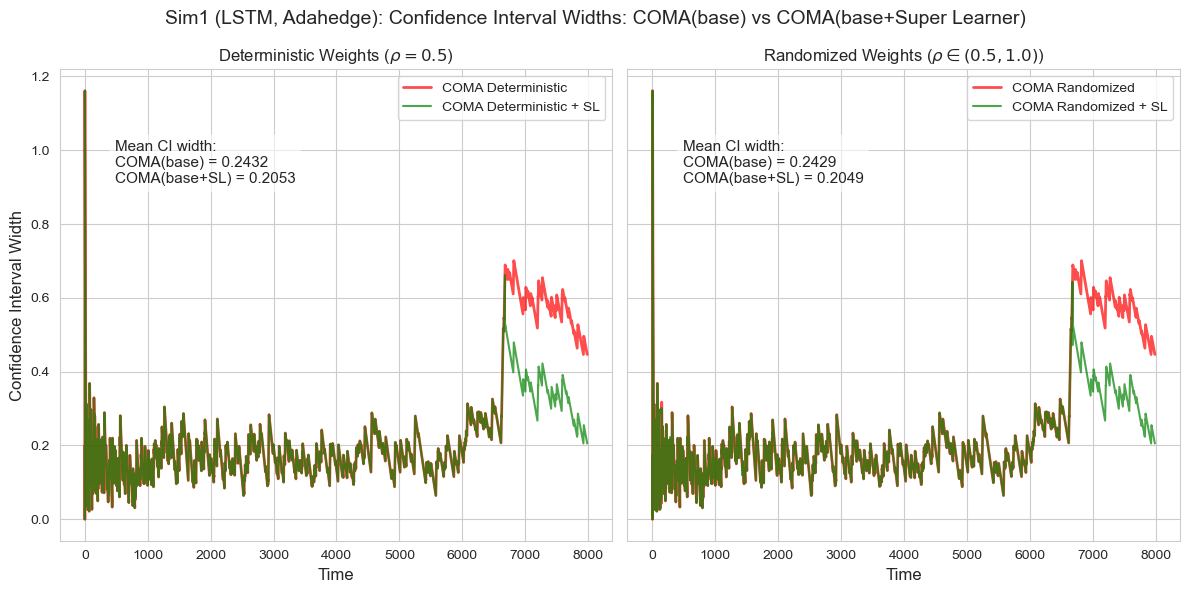

In [10]:

min_len = min(
    len(results_jd_lstm1['q_decaying']),
    len(results_jd_lstm2['q_decaying']),
    len(results_jd_lstm3['q_decaying']),
    #len(results_jd_lstm3_model2['q_decaying']),
    len(results_super_lstm['q_decaying']),
    len(y_true_test)
)

ci_matrix_sl = np.column_stack([
    CI_lstm_decaying_model1[-min_len:],
    CI_lstm_decaying_model2[-min_len:],
    #2 * results_jd_srm_model2['q_decaying'][-min_len:],
    CI_lstm_decaying_model3[-min_len:],
    CI_sp_decaying[-min_len:]
])
adahedAlg_sl = adahedge(loss_matrix=ci_matrix_sl)

intervals_lstm1 = np.column_stack([
    y_pred_lstm1[-min_len:] - results_jd_lstm1['q_decaying'][-min_len:],
    y_pred_lstm1[-min_len:] + results_jd_lstm1['q_decaying'][-min_len:]
])

intervals_lstm2 = np.column_stack([
    y_pred_lstm2[-min_len:] - results_jd_lstm2['q_decaying'][-min_len:],
    y_pred_lstm2[-min_len:] + results_jd_lstm2['q_decaying'][-min_len:]
])

intervals_lstm3 = np.column_stack([
    y_pred_lstm3[-min_len:] - results_jd_lstm3['q_decaying'][-min_len:],
    y_pred_lstm3[-min_len:] + results_jd_lstm3['q_decaying'][-min_len:]
])



intervals_sp = np.column_stack([
    super_preds_lstm[-min_len:] - results_super_lstm['q_decaying'][-min_len:],
    super_preds_lstm[-min_len:] + results_super_lstm['q_decaying'][-min_len:]
])

# --- Step 4: Pack intervals + weights ---
intervals_list_sl = [intervals_lstm1, intervals_lstm2, intervals_lstm3, intervals_sp]
weights_sl = adahedAlg_sl["weights"]

# --- Step 5: Align test labels ---
y_test_aligned = y_true_test[-min_len:]

# --- Step 6: Run COMA ---
result_sl = coma_loop(intervals_list_sl, weights_sl, y_test_aligned)

print("Mean deterministic coverage:", result_sl["mean_m_cov"])
print("Mean randomized coverage:", result_sl["mean_wm_cov"])


# For the plain intervals (without Super Learner)
intervals_list_plain = [intervals_lstm1, intervals_lstm2, intervals_lstm3]
weights_plain = adahedAlg["weights"]

# --- Run COMA for plain (base learners only) ---
result_plain = coma_loop(intervals_list_plain, weights_plain, y_test_aligned)
# --- Step 7: Compute widths ---
pi_m_plain   = result_plain["pi_m"]
pi_wm_plain  = result_plain["pi_wm"]
coma_width_det  = np.array([loss_fun(ci) for ci in pi_m_plain])
coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm_plain])
# --- Step 7: Compute widths ---
pi_m_sl   = result_sl["pi_m"]
pi_wm_sl  = result_sl["pi_wm"]

coma_width_det_sl  = np.array([loss_fun(ci) for ci in pi_m_sl])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])

print("Mean CI width — COMA (det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA (det) + SL:", np.nanmean(coma_width_det_sl))
print("Mean CI width — COMA (rand) + SL:", np.nanmean(coma_width_rand_sl))

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Deterministic subplot ---
axes[0].plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha=0.7, color='red')
axes[0].plot(coma_width_det_sl, label='COMA Deterministic + SL', linewidth=1.5, alpha=0.7, color='green')
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

# Add mean values annotation
mean_det = np.nanmean(coma_width_det)
mean_det_sl = np.nanmean(coma_width_det_sl)
axes[0].text(0.1, 0.85,
             f"Mean CI width:\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.4f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

# --- Randomized subplot ---
axes[1].plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color='red')
axes[1].plot(coma_width_rand_sl, label='COMA Randomized + SL', linewidth=1.5, alpha=0.7, color='green')
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time", fontsize=12)
axes[1].legend()

# Add mean values annotation
mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
axes[1].text(0.1, 0.85,
             f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("Sim1 (LSTM, Adahedge): Confidence Interval Widths: COMA(base) vs COMA(base+Super Learner)", fontsize=14)
plt.tight_layout()
plt.show()

## Hedge 

Mean deterministic coverage (COMA base): 0.8981840951784597
Mean randomized coverage (COMA base): 0.8867877269881027
Mean deterministic coverage (COMA+SL): 0.8978083907326236
Mean randomized coverage (COMA+SL): 0.8832811521603006
Mean CI width — COMA(base, det): 0.2434837779109561
Mean CI width — COMA(base, rand): 0.23906064317993625
Mean CI width — COMA(base+SL, det): 0.20575688097272707
Mean CI width — COMA(base+SL, rand): 0.1970624478990532


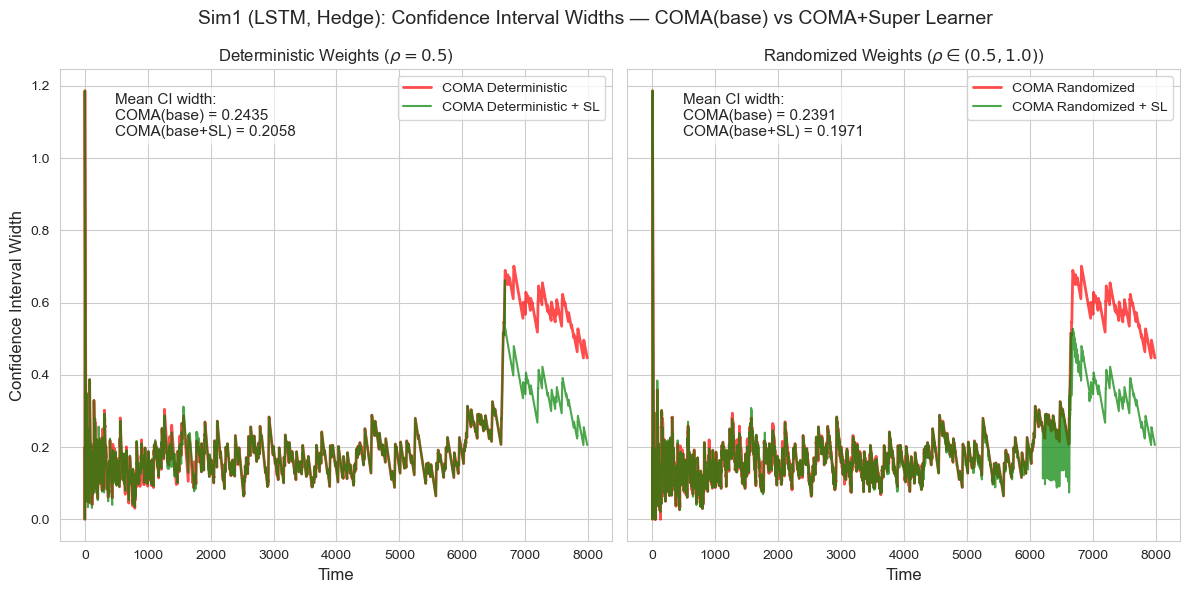

In [11]:
# --- Step 1: Run Hedge separately for base (3 experts) and base+SL (4 experts) ---
hedAlg_base = hedge(ci_matrix, eta=0.1)        # shape (N,3)
hedAlg_sl   = hedge(ci_matrix_sl, eta=0.1)     # shape (N,4)

weights_base = hedAlg_base["weights"]
weights_sl   = hedAlg_sl["weights"]

N_base, K_base = weights_base.shape
N_sl, K_sl     = weights_sl.shape

# Ensure alignment
min_len = min(len(y_true_test), N_base, N_sl)
y_test_aligned = y_true_test[-min_len:]

# --- Step 2: Preallocate ---
pi_m_base, pi_wm_base = [], []
pi_m_sl, pi_wm_sl     = [], []

m_cov_base = np.full(min_len, np.nan)
wm_cov_base = np.full(min_len, np.nan)
m_cov_sl   = np.full(min_len, np.nan)
wm_cov_sl  = np.full(min_len, np.nan)

# --- Step 3: Loop over time ---
for i in range(min_len):
    # --- Sample ONE rho per step and reuse for both base and base+SL ---
    rho_rand = np.random.uniform(0.5,1.0)

    # --- Base (3 experts) ---
    conf_base = np.vstack([intervals_list_plain[j][i] for j in range(3)])
    maj_int_base = majority_vote(conf_base, w=weights_base[i], rho=0.5)
    wmaj_int_base = majority_vote(conf_base, w=weights_base[i], rho=rho_rand)

    pi_m_base.append(maj_int_base)
    pi_wm_base.append(wmaj_int_base)
    m_cov_base[i]  = covr_fun(maj_int_base, y_test_aligned[i])
    wm_cov_base[i] = covr_fun(wmaj_int_base, y_test_aligned[i])

    # --- Base+SL (4 experts) ---
    conf_sl = np.vstack([intervals_list_sl[j][i] for j in range(4)])
    maj_int_sl = majority_vote(conf_sl, w=weights_sl[i], rho=0.5)
    wmaj_int_sl = majority_vote(conf_sl, w=weights_sl[i], rho=rho_rand)  # same rho_rand

    pi_m_sl.append(maj_int_sl)
    pi_wm_sl.append(wmaj_int_sl)
    m_cov_sl[i]  = covr_fun(maj_int_sl, y_test_aligned[i])
    wm_cov_sl[i] = covr_fun(wmaj_int_sl, y_test_aligned[i])

# --- Step 4: Compute widths ---
coma_width_det     = np.array([loss_fun(ci) for ci in pi_m_base])
coma_width_rand    = np.array([loss_fun(ci) for ci in pi_wm_base])
coma_width_det_sl  = np.array([loss_fun(ci) for ci in pi_m_sl])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])

# --- Step 5: Summaries ---
print("Mean deterministic coverage (COMA base):", np.nanmean(m_cov_base))
print("Mean randomized coverage (COMA base):", np.nanmean(wm_cov_base))
print("Mean deterministic coverage (COMA+SL):", np.nanmean(m_cov_sl))
print("Mean randomized coverage (COMA+SL):", np.nanmean(wm_cov_sl))

print("Mean CI width — COMA(base, det):", np.nanmean(coma_width_det))
print("Mean CI width — COMA(base, rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA(base+SL, det):", np.nanmean(coma_width_det_sl))
print("Mean CI width — COMA(base+SL, rand):", np.nanmean(coma_width_rand_sl))

# --- Step 7: Subplot comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# --- Deterministic subplot ---
axes[0].plot(coma_width_det, label='COMA Deterministic', linewidth=2, alpha=0.7, color='red')
axes[0].plot(coma_width_det_sl, label='COMA Deterministic + SL', linewidth=1.5, alpha=0.7, color='green')
axes[0].set_title("Deterministic Weights ($\\rho=0.5$)", fontsize=12)
axes[0].set_xlabel("Time", fontsize=12)
axes[0].set_ylabel("Confidence Interval Width", fontsize=12)
axes[0].legend()

# Annotate means
mean_det = np.nanmean(coma_width_det)
mean_det_sl = np.nanmean(coma_width_det_sl)
axes[0].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_det:.4f}\nCOMA(base+SL) = {mean_det_sl:.4f}",
             transform=axes[0].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

# --- Randomized subplot ---
axes[1].plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color='red')
axes[1].plot(coma_width_rand_sl, label='COMA Randomized + SL', linewidth=1.5, alpha=0.7, color='green')
axes[1].set_title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
axes[1].set_xlabel("Time", fontsize=12)
axes[1].legend()

# Annotate means
mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
axes[1].text(0.1, 0.95,
             f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
             transform=axes[1].transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

plt.suptitle("Sim1 (LSTM, Hedge): Confidence Interval Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.show()